In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles_f')
import funciones_aux_bootstrap_f_r as fab

Este es un bootstrap (bayesiano) de votos directo (suponiendo que se pudieran muestrear los votos).

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [4]:
def bootstrap_votos_dir_simple(df, num_boot: int=1000, n_vot_mue=2000, semilla=1):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Base con solo los votos de los candidatos
    df_cand=np.array(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum(0).astype(int))

    # Semilla para las muestras de la Dirichlet
    #rng = np.random.default_rng()

    # Semilla para los conteos de votos (eventualmente se tiene que mover adentro del for para que sea reproducible el código)
    #rng_2 = np.random.default_rng()

    for i in range(num_boot):


        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*semilla))
 
        # Muestra de votos (en este caso son 2000)
        # Lo correcto es utilizar la distribución hipergeométrica multivariada.
        votos_subm=rng.multivariate_hypergeometric(colors=df_cand, nsample=n_vot_mue)

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+1)))

        # Los pesos de la distribución Dirichlet
        pesos_bootstrap=rng.dirichlet(votos_subm, 1000)

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+2)))

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        #print(i)
        
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [468]:
# Boostrap por votos
inter_prob_v, est_punt_v=bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=2000, semilla=8)

In [5]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=5000)

881 ms ± 8.27 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [470]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=2000)

In [471]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,953,0.953,2000
1,RENAN_BARRERA_CONCHA,953,0.953,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,945,0.945,2000
3,VOTOS_NULOS_CAND_NO_REGIS,940,0.940,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,941,0.941,2000


In [395]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.470379,0.512251,0.041871,0.491746,0.515125,JOAQUIN_DIAZ_MENA,0.023380,2000,0.949
1,2,0.481384,0.525348,0.043964,0.503372,0.515125,JOAQUIN_DIAZ_MENA,0.011753,2000,0.949
2,3,0.511809,0.554658,0.042850,0.533195,0.515125,JOAQUIN_DIAZ_MENA,0.018070,2000,0.949
3,4,0.500603,0.544943,0.044340,0.521226,0.515125,JOAQUIN_DIAZ_MENA,0.006101,2000,0.949
4,5,0.491357,0.533321,0.041964,0.512117,0.515125,JOAQUIN_DIAZ_MENA,0.003008,2000,0.949
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.014084,0.026326,0.012242,0.019542,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001925,2000,0.937
4996,997,0.011272,0.022033,0.010761,0.016078,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.005389,2000,0.937
4997,998,0.022314,0.036701,0.014388,0.029055,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.007588,2000,0.937
4998,999,0.015028,0.027405,0.012377,0.020864,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000603,2000,0.937


In [32]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]
df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v]["Longitud_intervalo"].describe()

count    1000.000000
mean        0.043570
std         0.001254
min         0.039663
25%         0.042757
50%         0.043514
75%         0.044352
max         0.048868
Name: Longitud_intervalo, dtype: float64

In [11]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [12]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

In [13]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.010489,2000.0
std,288.819436,0.006335,0.0
min,1.000000,0.000842,2000.0
2.5%,25.975000,0.002277,2000.0
50%,500.500000,0.008978,2000.0
97.5%,975.025000,0.027235,2000.0
max,1000.000000,0.041028,2000.0


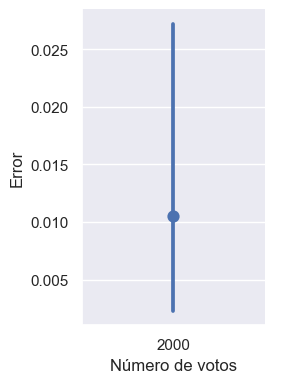

In [14]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Número de votos', ylabel='Error');

In [15]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.508193,0.552662,0.044468,0.530128,0.515125,JOAQUIN_DIAZ_MENA,0.015002,2000,0.964
1,2,0.492277,0.534626,0.042349,0.513365,0.515125,JOAQUIN_DIAZ_MENA,0.001760,2000,0.964
2,3,0.493471,0.536192,0.042721,0.514528,0.515125,JOAQUIN_DIAZ_MENA,0.000598,2000,0.964
3,4,0.486141,0.529737,0.043596,0.507332,0.515125,JOAQUIN_DIAZ_MENA,0.007794,2000,0.964
4,5,0.500108,0.543160,0.043052,0.521042,0.515125,JOAQUIN_DIAZ_MENA,0.005917,2000,0.964
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.021922,0.036672,0.014750,0.028948,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.007481,2000,0.955
4996,997,0.015262,0.027655,0.012393,0.021113,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000354,2000,0.955
4997,998,0.018701,0.031246,0.012545,0.024572,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003105,2000,0.955
4998,999,0.010212,0.019958,0.009746,0.014789,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.006678,2000,0.955


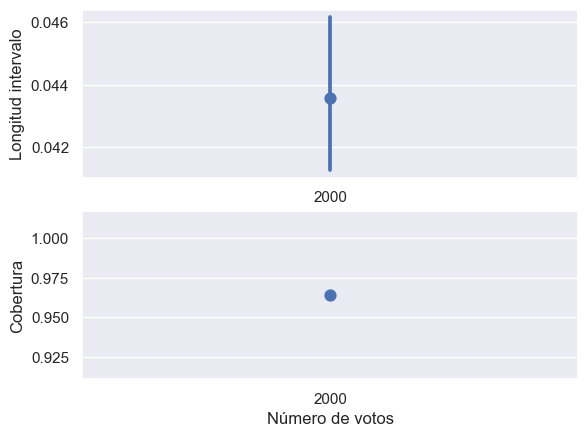

In [16]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Número de votos', ylabel='Longitud intervalo');
ax_2.set(xlabel='Número de votos', ylabel='Cobertura');


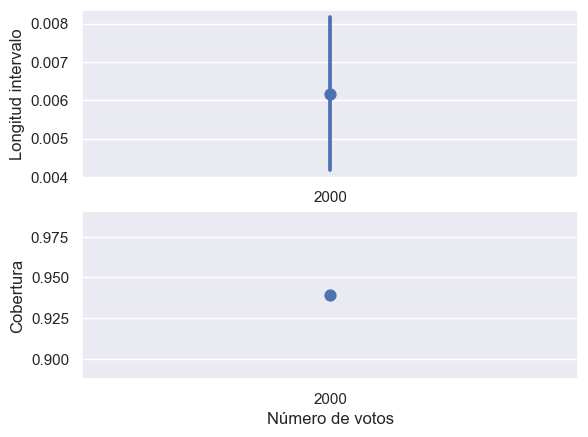

In [17]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Número de votos', ylabel='Longitud intervalo');
ax_2.set(xlabel='Número de votos', ylabel='Cobertura');

## Bootstraps con distintas muestras de votos

In [643]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
#muestra_votos = [500, 1000, 1500, 2000, 3000, 4000, 5000]
# Edición especial con 10000 y 20000 y quitando 1500 y 3000
muestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_se=pd.DataFrame()

# Contador para el for
k=0

for mv in muestra_votos:
    
        # Boostrap por votos (sin estratificar)
        inter_prob, est_punt=bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=mv, semilla=k+1)
        # Calculamos las métricas
        df_metr_boot, df_error_max, df_can_cob= fab.metricas_bootstrap(prop_reales, inter_prob, est_punt, porcenta_tama=mv)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_se.loc[k,"Tamaño_muestra_votos"]= mv

        # Las métricas para el error máximo
        df_boostraps_votos_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l_c=df_metr_boot.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob[df_can_cob["Candidato"]==candidato_int_m_l_c]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_int_m_l_c]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men=df_can_cob[df_can_cob["Cobertura"]==df_can_cob["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob[df_can_cob["Candidato"]==candidato_cober_men]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_cober_men]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mv)

Muestra casillas: 500
Muestra casillas: 1000
Muestra casillas: 2000
Muestra casillas: 5000
Muestra casillas: 10000
Muestra casillas: 20000


In [644]:
df_boostraps_votos_se

,Tamaño_muestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,500.0,0.004824,0.019602,0.051655,JOAQUIN_DIAZ_MENA,0.952,0.082131,0.087116,0.092539,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.910,0.000000,0.011112,0.019078,0.952,0.947,0.937,0.946,0.910
1,1000.0,0.003232,0.013484,0.039606,JOAQUIN_DIAZ_MENA,0.944,0.058242,0.061574,0.065029,VIDA_ARAVARI_GOMEZ_HERRERA,0.940,0.019216,0.023106,0.026770,0.944,0.956,0.940,0.955,0.951
2,2000.0,0.002248,0.009932,0.025851,JOAQUIN_DIAZ_MENA,0.950,0.041188,0.043621,0.046381,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.935,0.004111,0.006175,0.008155,0.950,0.944,0.948,0.950,0.935
3,5000.0,0.001491,0.006316,0.017107,JOAQUIN_DIAZ_MENA,0.940,0.025989,0.027615,0.029219,RENAN_BARRERA_CONCHA,0.935,0.025735,0.027276,0.028833,0.940,0.935,0.949,0.940,0.957
4,10000.0,0.001141,0.004368,0.011455,JOAQUIN_DIAZ_MENA,0.954,0.018488,0.019588,0.020744,VOTOS_NULOS_CAND_NO_REGIS,0.941,0.005159,0.005662,0.006162,0.954,0.953,0.955,0.941,0.961
5,20000.0,0.000794,0.002980,0.008404,JOAQUIN_DIAZ_MENA,0.943,0.013120,0.013913,0.014658,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.938,0.001779,0.002004,0.002236,0.943,0.950,0.943,0.958,0.938


In [645]:
# Guardamos en un csv
df_boostraps_votos_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Directo/Distintas_muestras_bootstrap_votos_dir_sin_est_f_1.csv")

## Estratificado

In [ ]:
# Versión función
def boot_votos_dir_estratificado(df_act_yuc_i, num_boot: int=1000, n_vot_mue=2000, semilla=1):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"]))

    # Guardamos en un numpy array el dataframe como los votos y el distrito de toda la base
    array_muest=np.array(df_act_yuc_i[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

    # Corrección porque el muestreo estratificado es de votos
    # Porcentaje del total de votos por estrato (distrito)
    array_pesos_normalizados_dist=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_act_yuc_i["TOTAL"].sum()).sort_index()["TOTAL"])

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    # Número de poblaciones
    n_boot=1000


    for i in range(num_boot):

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_mue).astype(int)

        # Los porcentajes de cada distrito de toda la muestra de votoss
        array_pesos_normalizados_mue=totales_prop_est/totales_prop_est.sum()

        # Hacemos que el código sea reproducible

        # Muestra de votos por distrito (estrato)
        # Lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        votos_subm_d=[np.random.default_rng(index+((i+1)+(num_boot*(semilla+1)))).multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1]) for index, val in enumerate(val_dist)]

        # Vector de pesos de la distribución Dirichlet
        # Hay que arreglar la función para que pueda aceptar valores con alfa igual a cero (que tengan probabilidad 0)
        vectores_dir=[fab.f_a(xi,n_boot, semilla=index+((i+1)+(num_boot*(semilla+2)))) for index, xi in enumerate(votos_subm_d)]

        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # Semilla para las muestras de la Multinomial
        #rng_2 = np.random.default_rng((num_boot*(semilla+4+i+1)))

        # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        for k in val_dist:

            # Semilla para las muestras de la Multinomial
            rng_2 = np.random.default_rng((num_boot*(semilla+3))+(i+1+k))
            
            # Total de votos de la muestra simulada (utilizando una multinomial)
            votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

            # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcanzar el 100%)
            array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_mue[k-1])

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales (del bootstrap)
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)

    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)
    # Los intervalos guardados
    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [615]:
inter_prob_v_est, est_punt_v_est=boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=2000, semilla=3)

In [8]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=5000)

9.96 s ± 567 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [617]:
# Cálculamos las métricas
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=2000)

In [618]:
df_can_cob_v_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,947,0.947,2000
1,RENAN_BARRERA_CONCHA,944,0.944,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,951,0.951,2000
3,VOTOS_NULOS_CAND_NO_REGIS,944,0.944,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,922,0.922,2000


In [619]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=250
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [620]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [621]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.010787,2000.0
std,288.819436,0.006206,0.0
min,1.000000,0.000890,2000.0
2.5%,25.975000,0.002746,2000.0
50%,500.500000,0.009463,2000.0
97.5%,975.025000,0.025697,2000.0
max,1000.000000,0.039180,2000.0


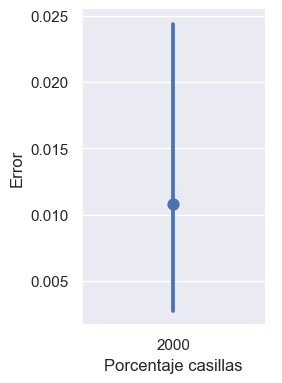

In [11]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [12]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.499539,0.542128,0.042589,0.521080,0.515125,JOAQUIN_DIAZ_MENA,0.005955,2000,0.964
1,2,0.499539,0.542128,0.042589,0.521080,0.515125,JOAQUIN_DIAZ_MENA,0.005955,2000,0.964
2,3,0.503457,0.546597,0.043140,0.524280,0.515125,JOAQUIN_DIAZ_MENA,0.009154,2000,0.964
3,4,0.503457,0.546597,0.043140,0.524280,0.515125,JOAQUIN_DIAZ_MENA,0.009154,2000,0.964
4,5,0.483642,0.525276,0.041634,0.504307,0.515125,JOAQUIN_DIAZ_MENA,0.010818,2000,0.964
...,...,...,...,...,...,...,...,...,...,...
9995,1996,0.015240,0.028841,0.013600,0.021264,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000203,2000,0.945
9996,1997,0.016839,0.029967,0.013128,0.023069,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001602,2000,0.945
9997,1998,0.016839,0.029967,0.013128,0.023069,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001602,2000,0.945
9998,1999,0.018643,0.032147,0.013504,0.024658,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003191,2000,0.945


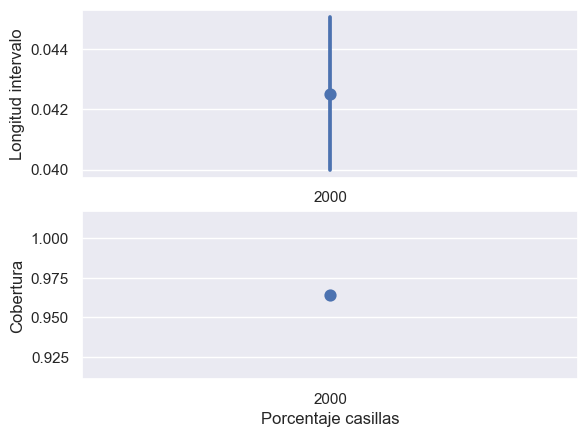

In [13]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


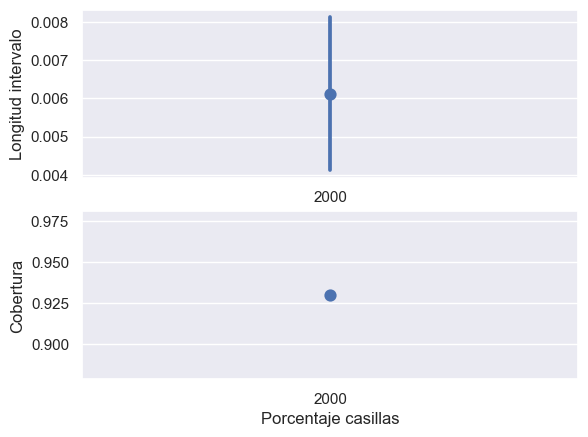

In [14]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

## Bootstraps con distintas muestras de votos

In [640]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
#muestra_votos = [500, 1000, 1500, 2000, 3000, 4000, 5000]
# Edición especial con 10000 y 20000 y quitando 1500 y 3000

muestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_est=pd.DataFrame()

# Contador para el for
k=0

for mv in muestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
    
        # Boostrap por votos (sin estratificar)
        inter_prob_v_est, est_punt_v_est=boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=mv, semilla=k+1)
        # Calculamos las métricas
        df_metr_boot_c_v_est, df_error_max_v_est, df_can_cob_v_est=fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mv)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_est.loc[k,"Tamaño_muestra_votos"]= mv

        # Las métricas para el error máximo
        df_boostraps_votos_est.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l_c_est=df_metr_boot_c_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c_est
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_int_m_l_c_est]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_est.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_int_m_l_c_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_est
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_est.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_cober_men_est]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_est.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_est.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v_est.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra votos:", mv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

Muestra votos: 500
Tiempo que tarda correr una iteración del for 6.8478429317474365
Muestra votos: 1000
Tiempo que tarda correr una iteración del for 7.497483015060425
Muestra votos: 2000
Tiempo que tarda correr una iteración del for 8.291162252426147
Muestra votos: 5000
Tiempo que tarda correr una iteración del for 8.800551891326904
Muestra votos: 10000
Tiempo que tarda correr una iteración del for 9.008392095565796
Muestra votos: 20000
Tiempo que tarda correr una iteración del for 9.602569818496704


In [641]:
df_boostraps_votos_est

,Tamaño_muestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,500.0,0.005021,0.018552,0.051851,JOAQUIN_DIAZ_MENA,0.945,0.077322,0.082268,0.087524,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.910,0.000000,0.011175,0.018151,0.945,0.940,0.939,0.948,0.910
1,1000.0,0.003471,0.013150,0.037429,JOAQUIN_DIAZ_MENA,0.935,0.055919,0.059364,0.063030,VOTOS_NULOS_CAND_NO_REGIS,0.928,0.013176,0.017197,0.021018,0.935,0.936,0.944,0.928,0.943
2,2000.0,0.002746,0.009463,0.025697,JOAQUIN_DIAZ_MENA,0.947,0.040017,0.042394,0.045042,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.922,0.003949,0.006035,0.008049,0.947,0.944,0.951,0.944,0.922
3,5000.0,0.001620,0.005668,0.016700,JOAQUIN_DIAZ_MENA,0.954,0.025416,0.027065,0.028765,VOTOS_NULOS_CAND_NO_REGIS,0.945,0.007006,0.007878,0.008736,0.954,0.948,0.950,0.945,0.948
4,10000.0,0.001038,0.004165,0.012007,JOAQUIN_DIAZ_MENA,0.948,0.018129,0.019225,0.020406,VIDA_ARAVARI_GOMEZ_HERRERA,0.943,0.006781,0.007308,0.007854,0.948,0.947,0.943,0.973,0.956
5,20000.0,0.000758,0.002843,0.007663,JOAQUIN_DIAZ_MENA,0.962,0.012800,0.013615,0.014414,VOTOS_NULOS_CAND_NO_REGIS,0.943,0.003739,0.004027,0.004329,0.962,0.962,0.948,0.943,0.953


In [642]:
# Guardamos en un csv
df_boostraps_votos_est.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Directo/Distintas_muestras_bootstrap_votos_dir_estratificado_f_1.csv")